# Codificación Superdensa en Qiskit

Qiskit es el SDK (Software Development Kit) de IBM para Computación Cuántica

1. **QuantumCircuit** simula las operaciones (como las compuertas) cuánticas
2. **QuantumRegister** retiene a los qubits. al realizar operaciones, nos referimos a los índices asociados a esta librería
3. **ClassicalRegister** retiene los resultados de las mediciones, las cuales toman formas de bits clasicos
4. **Aer** Simula el backend de un computador cuántico clásicamente
5. **transpile** reescribe el input de un circuito para adaptarlo a un especifico dispositivo cuantica, y ademas optimiza las instrucciones del circuito para reducir el ruido cuántico

In [3]:
%matplotlib inline
#Esto solo si quiero imprimirlo bonito con formato "mpl"
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

Ahora, construimos el circuito en sí

Resultados de Codificación superdensa:
------------------------------------------------------------
Mensaje Originario (Alice) : 00
Señal Reconstruida (Bob)   : ['00']
Conteo de resultados (shots): {'00': 2048}
------------------------------------------------------------
Mensaje Originario (Alice) : 01
Señal Reconstruida (Bob)   : ['01']
Conteo de resultados (shots): {'01': 2048}
------------------------------------------------------------
Mensaje Originario (Alice) : 10
Señal Reconstruida (Bob)   : ['10']
Conteo de resultados (shots): {'10': 2048}
------------------------------------------------------------
Mensaje Originario (Alice) : 11
Señal Reconstruida (Bob)   : ['11']
Conteo de resultados (shots): {'11': 2048}
------------------------------------------------------------

Diagrama del Circuito Cuántico (mensaje '11'):


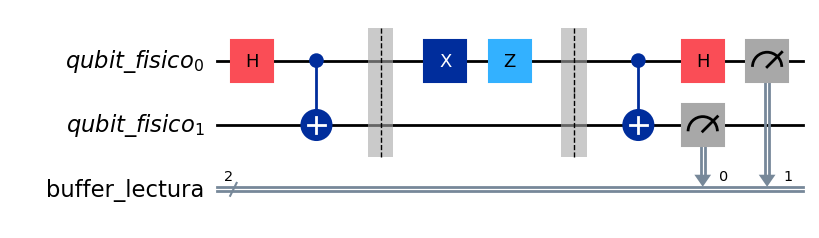

In [7]:
def fabricar_circuito_superdenso(mensaje_clasico_binario):
    """
    Ensambla la topología completa del protocolo de codificación superdensa 
    para la inyección de dos bits clásicos de información 
    ('00', '01', '10', o '11').
    """
    # Verificación de que los datos fueron enviados correctamente
    if mensaje_clasico_binario not in ['00', '01', '10', '11']:
        raise ValueError("Excepción: El bloque de mensaje debe pertenecer al conjunto ortogonal '00', '01', '10' o '11'.")
        
    # Extracción de bits para condicionales operativos de Alice
    bit_c = mensaje_clasico_binario[0] #Extraigo el primer bit del string
    bit_d = mensaje_clasico_binario[1] #y el segundo bit del string
    #c y d con tal de no mezclarlo con alice y bob

    # Declaración de la informacion a trabajar.
    # qr aloja el estado de Hilbert para la generación del par EPR.
    qr = QuantumRegister(2, 'qubit_fisico')
    # cr reserva búferes de memoria RAM clásica para almacenar el colapso final.
    cr = ClassicalRegister(2, 'buffer_lectura')
    # qc crea el circuito combinando los qubits cuanticos y clasicos en un solo objeto
    qc = QuantumCircuit(qr, cr, name="Protocolo_Superdense")

    # ==========================================
    # PASO 1: Preparacion del estado de Bell
    # ==========================================
    # El sistema arranca de manera implícita en el vector |00>.

    
    #Primero, se transforma el qubit 0 de Alice con la compuerta de Hadamard para transformarlo
    #en una superposicion.
    qc.h(0)
    
    # Se inyecta la no-localidad accionando el control-not (CNOT).
    # Qubit 0 es el control direccional, Qubit 1 (Bob) es el objetivo de paridad.
    # El estado global transiciona hacia el par de Bell |Φ+>.
    qc.cx(0, 1)
    

    # ==========================================
    # PASO 2: Codificación Aislada y Modulación
    # ==========================================
    qc.barrier() #Se agrega por estética al dibujar el circuito
    # Dependiendo de la variable 'bit_d', Alice efectúa la inversión rotacional (X)
    if bit_d == '1':
        qc.x(0)
    
    # Dependiendo de la variable 'bit_c', Alice aplica la distorsión de fase (Z)
    if bit_c == '1':
        qc.z(0)
        
    #Notar que en la literatura, a veces se va a ver iY en lugar de XZ, pero recordar que son formas equivalentes
    
    qc.barrier()

    # ==========================================
    # PASO 3: Decodificacion del estado Bell
    # ==========================================
    # Bob recibe el Qubit 0 en su ensamblaje. Reversamos el entrelazamiento.
    qc.cx(0, 1)     #Basta con aplicar las compuertas de nuevo,
    qc.h(0)         #al ser transformaciones unitarias

    # ==========================================
    # PASO 4: Evaluacion proyectiva
    # ==========================================
    # Medición destructiva de la función de onda de Schrödinger.
    # Se mapean explícitamente los qubits colapsados a direcciones precisas de RAM.
    qc.measure(0, 1)
    qc.measure(1, 0)
    return qc

### MAIN ###

# Instanciación del procesador virtual cuántico
simulador_cuantico = AerSimulator()

print("Resultados de Codificación superdensa:")
print("-" * 60)

# Iteración sobre todos los mensajes posibles
for bloque_mensaje in ['00', '01', '10', '11']:
    
    # 1. Moldeado del Circuito
    grafo_circuito = fabricar_circuito_superdenso(bloque_mensaje)
    
    # 2. Transpilación a ISA (Arquitectura de Conjunto de Instrucciones) nativa
    circuito_optimizado = transpile(grafo_circuito, simulador_cuantico)
    
    # 3. Lanzamiento del trabajo asíncrono con 1024 muestreos estadísticos (shots)
    #Este numer
    trabajo_ejecucion = simulador_cuantico.run(circuito_optimizado, shots=2048)
    objeto_resultados = trabajo_ejecucion.result()
    diccionario_conteos = objeto_resultados.get_counts()
    
    # 4. Evaluación de métricas
    mensaje_recibido_mayoritario = list(diccionario_conteos.keys())
    
    print(f"Mensaje Originario (Alice) : {bloque_mensaje}")
    print(f"Señal Reconstruida (Bob)   : {mensaje_recibido_mayoritario}")
    print(f"Conteo de resultados (shots): {diccionario_conteos}")
    print("-" * 60)

# ==========================================
# Visualización del Circuito y Resultados
# ==========================================

# Generar el circuito para cualquier mensaje (usamos '11' como ejemplo completo
# porque es el único que activa AMBAS compuertas X y Z, mostrando el circuito completo)
circuito_visual = fabricar_circuito_superdenso('11')

# Imprimir el diagrama del circuito en consola
# Las barreras qc.barrier() aparecen aquí como líneas divisorias ░
print("\nDiagrama del Circuito Cuántico (mensaje '11'):")
dibujo = circuito_visual.draw(output='mpl') #Se puede ver mas bonito con "mpl", pero para esto se
    #ocupa instalar matplotlib, pylatexenc, sino usar "text"
